# Supplementary Module 4: GeoPandas
<a target="_blank" href="https://colab.research.google.com/github/yalinli2/EnvEtools/blob/main/course_modules/S4_GeoPandas.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a target="_blank" href="https:///mybinder.org/v2/gh/yalinli2/EnvEtools/main?urlpath=%2Fdoc%2Ftree%2Fcourse_modules%S4F2_GeoPandas.ipynb">
  <img src="https://mybinder.org/badge_logo.svg" alt="Open In Binder"/>
</a>


`GeoPandas` is used for for spatial data analysis in Python. `GeoPandas` extends `pandas` so that tabular data can also include a **geometry** column.

That means each row can represent a spatial feature such as:

- a **point** (for example, a sampling location)
- a **line** (for example, a river or road)
- a **polygon** (for example, a watershed or administrative boundary)

`GeoPandas` makes it easier to:

- store spatial data in tables
- plot maps
- work with coordinate systems
- do operations like buffering, clipping, and spatial joins

### Environmental Applications
GeoPandas is especially useful for tasks such as:

- mapping sampling locations
- overlaying infrastructure and environmental features
- watershed and land-use analysis
- environmental justice screening
- spatially explicit waste, energy, or emissions inventories
- joining monitoring data to administrative boundaries

It is often used together with:

- **pandas** for tabular analysis
- **matplotlib** for plotting
- **rasterio** for raster data
- **shapely** for geometry operations
- **contextily** for adding basemaps


## Learning Goals

By the end of this notebook, you should be able to:

- understand geospatial data structures in Python, including GeoDataFrames and geometry types (points, lines, polygons)
- load and inspect spatial datasets, including attributes and coordinate reference systems (CRS)
- perform basic spatial operations, such as reprojection, buffering, and spatial filtering
- combine datasets using spatial joins to relate geographic features
- create simple maps and export spatial data for further analysis or visualization.


## Core Concepts

A `GeoDataFrame` looks like a pandas DataFrame, but it has:

- a **geometry** column
- a **CRS** (coordinate reference system)


### Geometry types

GeoPandas can store different kinds of geometry.

#### Points
The station example above is an example of point geometry.

In [1]:
# Uncomment this line if GeoPandas is not installed
# !pip install geopandas

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

print("pandas version:", pd.__version__)
print("geopandas version:", gpd.__version__)

pandas version: 3.0.1
geopandas version: 1.1.3


In [2]:
# Example monitoring stations
df = pd.DataFrame({
    "station": ["A", "B", "C", "D"],
    "longitude": [-74.45, -74.42, -74.39, -74.36],
    "latitude": [40.50, 40.53, 40.51, 40.55],
    "nitrate_mgL": [3.2, 5.1, 2.8, 4.4]
})

df

,station,longitude,latitude,nitrate_mgL
0,A,-74.45,40.50,3.2
1,B,-74.42,40.53,5.1
2,C,-74.39,40.51,2.8
3,D,-74.36,40.55,4.4


In [3]:
# Convert longitude/latitude columns into Point geometry

from shapely.geometry import Point

# Unlike traditional mapping, longitude (x) comes before latitude (y) in the Point constructor
points = [Point(df.longitude[n], df.latitude[n]) for n in range(len(df.longitude))]

gdf_points = gpd.GeoDataFrame(
    df,
    geometry=points, # or gpd.points_from_xy(df["longitude"], df["latitude"])
    crs="EPSG:4326"   # WGS84 geographic coordinates
)

gdf_points


,station,longitude,latitude,nitrate_mgL,geometry
0,A,-74.45,40.50,3.2,POINT (-74.45 40.5)
1,B,-74.42,40.53,5.1,POINT (-74.42 40.53)
2,C,-74.39,40.51,2.8,POINT (-74.39 40.51)
3,D,-74.36,40.55,4.4,POINT (-74.36 40.55)


In [4]:
print(gdf_points.geometry)
print()
print("CRS:", gdf_points.crs)

0     POINT (-74.45 40.5)
1    POINT (-74.42 40.53)
2    POINT (-74.39 40.51)
3    POINT (-74.36 40.55)
Name: geometry, dtype: geometry

CRS: EPSG:4326



GeoPandas can make simple maps directly.


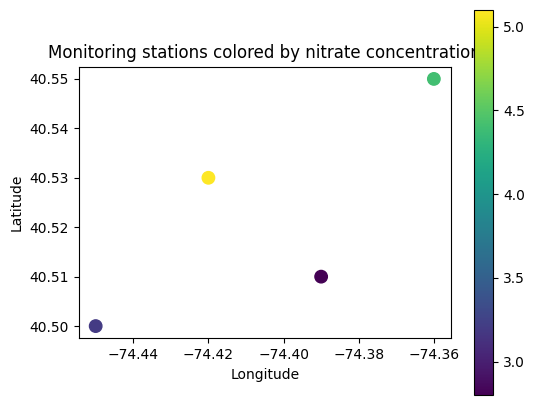

In [5]:
ax = gdf_points.plot(
    figsize=(6, 5),
    column="nitrate_mgL",
    legend=True,
    markersize=80
)

ax.set_title("Monitoring stations colored by nitrate concentration")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


To create a `GeoDataFrame`, a common workflow is to start with a normal table containing longitude and latitude, then add geometry and coordinate information.



#### LineString
A line can represent something like a stream reach or pipeline.


In [6]:
from shapely.geometry import LineString

stream = LineString([
    (-74.47, 40.49),
    (-74.43, 40.515),
    (-74.38, 40.54),
    (-74.34, 40.57)
])

gdf_line = gpd.GeoDataFrame(
    {"name": ["Stream 1"]},
    geometry=[stream],
    crs="EPSG:4326"
)

gdf_line

,name,geometry
0,Stream 1,"LINESTRING (-74.47 40.49, -74.43 40.515, -74.3..."


#### Polygon

A polygon can represent a management zone, site boundary, watershed, or neighborhood.


In [7]:
from shapely.geometry import Polygon

zone = Polygon([
    (-74.46, 40.495),
    (-74.46, 40.545),
    (-74.37, 40.545),
    (-74.37, 40.495)
])

gdf_polygon = gpd.GeoDataFrame(
    {"zone": ["Study Area"]},
    geometry=[zone],
    crs="EPSG:4326"
)

gdf_polygon

,zone,geometry
0,Study Area,"POLYGON ((-74.46 40.495, -74.46 40.545, -74.37..."


#### Comparison

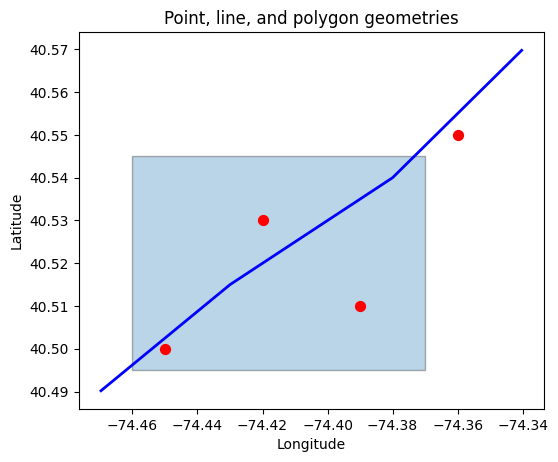

In [8]:
ax = gdf_polygon.plot(figsize=(6, 5), alpha=0.3, edgecolor="black")
gdf_line.plot(ax=ax, color="blue", linewidth=2)
gdf_points.plot(ax=ax, color="red", markersize=50)

ax.set_title("Point, line, and polygon geometries")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

### Coordinate Reference Systems (CRS)

The **CRS** tells `GeoPandas` how coordinates relate to real places on Earth.

Two very common cases are:

- **Geographic CRS (GCS)**: coordinates are in longitude/latitude degrees  
  - Example: [EPSG:4326](https://epsg.io/4326) (used in GPS)
- **Projected CRS (PCS)**: coordinates are in linear units such as meters or feet  
  - Better for distance, area, and buffering calculations

*EPSG is [European Petroleum Survey Group](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset)*

---

**Check out this fun and easy-to-understand [ArcGIS blog](https://www.esri.com/arcgis-blog/products/arcgis-pro/mapping/gcs_vs_pcs) on GCS and PCS!**

---

In [9]:
print("Current CRS:", gdf_points.crs)

# Reproject to Web Mercator (meters)
gdf_points_3857 = gdf_points.to_crs("EPSG:3857")
print("Projected CRS:", gdf_points_3857.crs)

gdf_points_3857.head()

Current CRS: EPSG:4326
Projected CRS: EPSG:3857


,station,longitude,latitude,nitrate_mgL,geometry
0,A,-74.45,40.50,3.2,POINT (-8287736.09 4938869.176)
1,B,-74.42,40.53,5.1,POINT (-8284396.505 4943262.003)
2,C,-74.39,40.51,2.8,POINT (-8281056.92 4940333.233)
3,D,-74.36,40.55,4.4,POINT (-8277717.335 4946191.647)


Notice that the geometry coordinates are now much larger numbers. That is because they are no longer longitude/latitude degrees; they are projected coordinates in meters.


In [10]:
# Compare distances between Station A and Station B
dist_deg = gdf_points.geometry.iloc[0].distance(gdf_points.geometry.iloc[1])
dist_m = gdf_points_3857.geometry.iloc[0].distance(gdf_points_3857.geometry.iloc[1])

print(f"Distance in EPSG:4326 (degrees): {dist_deg:.6f}")
print(f"Distance in EPSG:3857 (meters, approximate): {dist_m:.2f}")

Distance in EPSG:4326 (degrees): 0.042426
Distance in EPSG:3857 (meters, approximate): 5518.13


### Buffer

A **buffer** creates an area around a feature.

Examples:
- 100 m around a monitoring well
- 500 m around a school
- 1 km around a facility

Because buffer distance is usually in meters, we first use a projected CRS.


In [11]:
# Create 1000 m buffers around stations
buffers = gdf_points.to_crs("EPSG:3857").copy()
buffers["geometry"] = buffers.buffer(1000)

buffers.head()

,station,longitude,latitude,nitrate_mgL,geometry
0,A,-74.45,40.50,3.2,"POLYGON ((-8286736.09 4938869.176, -8286740.90..."
1,B,-74.42,40.53,5.1,"POLYGON ((-8283396.505 4943262.003, -8283401.3..."
2,C,-74.39,40.51,2.8,"POLYGON ((-8280056.92 4940333.233, -8280061.73..."
3,D,-74.36,40.55,4.4,"POLYGON ((-8276717.335 4946191.647, -8276722.1..."


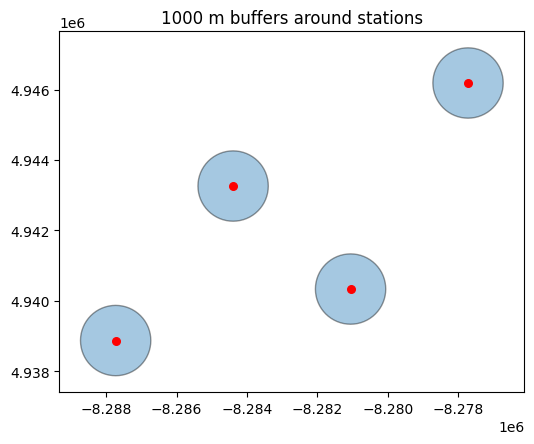

In [12]:
ax = buffers.plot(figsize=(6, 5), alpha=0.4, edgecolor="black")
gdf_points.to_crs("EPSG:3857").plot(ax=ax, color="red", markersize=30)

ax.set_title("1000 m buffers around stations")
plt.show()

### Spatial relationships

GeoPandas supports many spatial relationship tests, such as:

- `within`
- `contains`
- `intersects`
- `touches`

Let's test whether each station falls inside the study-area polygon.


In [13]:
# Make sure both layers use the same CRS
points_same_crs = gdf_points.to_crs(gdf_polygon.crs)

study_area = gdf_polygon.geometry.iloc[0]
gdf_points["inside_zone"] = points_same_crs.within(study_area)

gdf_points[["station", "inside_zone", "geometry"]]

,station,inside_zone,geometry
0,A,True,POINT (-74.45 40.5)
1,B,True,POINT (-74.42 40.53)
2,C,True,POINT (-74.39 40.51)
3,D,False,POINT (-74.36 40.55)


**Hint:** Check out the figure above for the relative location of A-D and the polygon.

### Spatial join

A **spatial join** combines attributes based on location rather than on a shared ID.

For example:
- assign each point to a polygon
- attach census tract data to sampling sites
- determine which wells fall inside a watershed

Below we create two polygons so each station can be assigned to a region.


In [14]:
west_zone = Polygon([
    (-74.47, 40.49),
    (-74.47, 40.57),
    (-74.405, 40.57),
    (-74.405, 40.49)
])

east_zone = Polygon([
    (-74.405, 40.49),
    (-74.405, 40.57),
    (-74.33, 40.57),
    (-74.33, 40.49)
])

regions = gpd.GeoDataFrame(
    {
        "region": ["West", "East"],
        "geometry": [west_zone, east_zone]
    },
    crs="EPSG:4326"
)

regions

,region,geometry
0,West,"POLYGON ((-74.47 40.49, -74.47 40.57, -74.405 ..."
1,East,"POLYGON ((-74.405 40.49, -74.405 40.57, -74.33..."


In [15]:
# Spatial join: assign each point to a region
joined = gpd.sjoin(
    gdf_points,
    regions,
    how="left",
    predicate="within"
)

joined[["station", "nitrate_mgL", "region", "geometry"]]

,station,nitrate_mgL,region,geometry
0,A,3.2,West,POINT (-74.45 40.5)
1,B,5.1,West,POINT (-74.42 40.53)
2,C,2.8,East,POINT (-74.39 40.51)
3,D,4.4,East,POINT (-74.36 40.55)


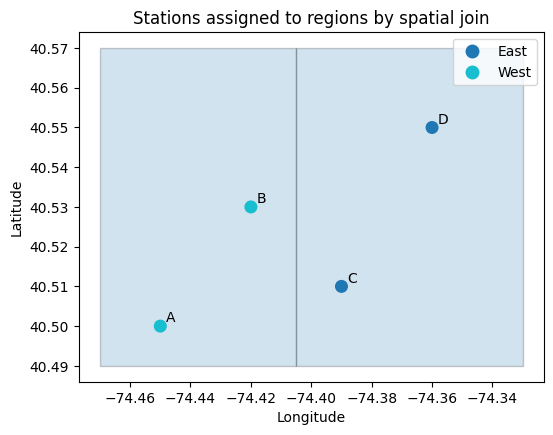

In [16]:
ax = regions.plot(figsize=(6, 5), alpha=0.2, edgecolor="black")
joined.plot(ax=ax, column="region", legend=True, markersize=70)

for x, y, label in zip(joined.geometry.x, joined.geometry.y, joined["station"]):
    ax.text(x + 0.002, y + 0.001, label)

ax.set_title("Stations assigned to regions by spatial join")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## Basic operations

### DataFrame operations

Because a `GeoDataFrame` is still a `DataFrame` (i.e., table), you can use many familiar pandas operations.

In [17]:
# Example: average nitrate by region
joined.groupby("region")["nitrate_mgL"].mean()

region
East    3.60
West    4.15
Name: nitrate_mgL, dtype: float64

In [18]:
# Example: filter stations above a threshold
high_nitrate = joined[joined["nitrate_mgL"] > 4.0]
high_nitrate

,station,longitude,latitude,nitrate_mgL,geometry,inside_zone,index_right,region
1,B,-74.42,40.53,5.1,POINT (-74.42 40.53),True,0,West
3,D,-74.36,40.55,4.4,POINT (-74.36 40.55),False,1,East


### Area and length calculations

Again, these calculations should usually be done in a **projected CRS**.


In [19]:
regions_m2 = regions.to_crs("EPSG:3857")
line_m = gdf_line.to_crs("EPSG:3857")

regions_m2["area_m2"] = regions_m2.area
line_m["length_m"] = line_m.length

print(regions_m2[["region", "area_m2"]])
print()
print(line_m[["name", "length_m"]])

  region       area_m2
0   West  8.478024e+07
1   East  9.782336e+07

       name      length_m
0  Stream 1  18682.965898


### Save spatial data

GeoPandas can write several formats, including:

- GeoJSON
- Shapefile
- GeoPackage
- Parquet

GeoJSON is often convenient for simple sharing.


In [ ]:
# Save to GeoJSON
output_path = "stations.geojson"
# gdf_points.to_file(output_path, driver="GeoJSON")

print(f"Saved to {output_path}")

Saved to stations.geojson


---

### JSON
**JSON (JavaScript Object Notation)** is a lightweight format used to store and exchange structured data.

It is widely used for:
- Web APIs
- Data storage
- Configuration files

JSON represents data using **key–value pairs** and looks very similar to a Python dictionary.

```json
{
  "name": "Alice",
  "age": 25,
  "is_student": true
}
```

Python uses the **json** library to convert data between Python objects and JSON.



In [21]:
# `json.dumps()` converts Python → JSON string
import json

data = {
    "city": "Singapore",
    "temperature_C": 30,
    "humidity": 0.75
}

json_string = json.dumps(data)
json_string

'{"city": "Singapore", "temperature_C": 30, "humidity": 0.75}'

In [22]:
# Convert JSON Back to Python
data_back = json.loads(json_string)
data_back

{'city': 'Singapore', 'temperature_C': 30, 'humidity': 0.75}

---

## Takeaways

GeoPandas is essentially **pandas + geometry + CRS awareness**.

Once you understand these ideas:

- geometry column
- CRS
- projection
- spatial relationship

you can already do a large amount of useful geospatial analysis in Python.


A very common GeoPandas workflow looks like this:

1. Read or create spatial data
2. Check the CRS
3. Reproject if needed
4. Perform spatial operations
5. Plot and interpret
6. Export results

## Exercises

Try these on your own:

1. Add one more station to the point dataset.
2. Create a 500 m buffer instead of 1000 m.
3. Compute the number of stations in each region.
4. Change the nitrate threshold from 4.0 to 3.5.
5. Save the joined dataset to a GeoJSON file.
6. Create a new polygon layer representing a "protected area" and test which stations fall inside it.
